In [8]:
# ============================================================
# QUANTUM NETWORK MULTI-HOP EMULATION
# ============================================================
# This notebook tests multi-hop quantum state transport across
# multiple nodes on the IBM Fez topology.
#
# Uses the network_emulation package for modular functions.
# ============================================================

import sys
import numpy as np
from pathlib import Path

# Add parent directory to path for network_emulation package
sys.path.insert(0, '..')

# Import from network_emulation package
from network_emulation import (
    # Node utilities
    Node, NODE_NAMES, NUM_NODES, INITIAL_STATES, STATE_LABELS,
    CONNECTION_TUPLES, node_name, route_name,
    # Config loading
    load_nodes_config, load_routes_config,
    # Circuit building (including new multi-hop function)
    build_swapping_circuit, build_multihop_swapping_circuit,
    # Experiment execution
    initialize_backend, run_single_experiment, run_full_experiment,
    # Visualization & export
    plot_syndrome_matrix, plot_all_states_comparison, plot_state_averages_bar,
    print_matrix_summary, print_full_comparison, save_results_to_json
)

print("Imports complete - using network_emulation package")
print("  - build_multihop_swapping_circuit() now available")

Imports complete - using network_emulation package
  - build_multihop_swapping_circuit() now available


In [9]:
# ============================================================
# EXPERIMENT CONFIGURATION
# ============================================================
# Set USE_REAL_HARDWARE = True to run on actual IBM quantum hardware
# Set USE_REAL_HARDWARE = False to use the FakeFez simulator
# ============================================================

USE_REAL_HARDWARE = False  # Toggle between real hardware and simulator

# Experiment parameters
NUM_SHOTS = 4096           # Number of shots per circuit execution
OPTIMIZATION_LEVEL = 0      # Transpiler optimization (0 = no optimization)

# Configuration file paths
CONFIG_DIR = Path('../configs')
NODES_FILE = CONFIG_DIR / 'config_1_nodes.json'
ROUTES_FILE = CONFIG_DIR / 'config_1_routes.json'
OUTPUT_DIR = Path('../outputs/syndromes')

print("="*60)
print("EXPERIMENT CONFIGURATION")
print("="*60)
print(f"Hardware mode:      {'REAL IBM HARDWARE' if USE_REAL_HARDWARE else 'FakeFez SIMULATOR'}")
print(f"Shots per circuit:  {NUM_SHOTS}")
print(f"Optimization level: {OPTIMIZATION_LEVEL}")
print(f"Initial states:     {[STATE_LABELS[s] for s in INITIAL_STATES]}")
print(f"\nConfig files:")
print(f"  Nodes:  {NODES_FILE} (exists: {NODES_FILE.exists()})")
print(f"  Routes: {ROUTES_FILE} (exists: {ROUTES_FILE.exists()})")

EXPERIMENT CONFIGURATION
Hardware mode:      FakeFez SIMULATOR
Shots per circuit:  4096
Optimization level: 0
Initial states:     ['|0⟩', '|1⟩', '|+⟩', '|−⟩']

Config files:
  Nodes:  ../configs/config_1_nodes.json (exists: True)
  Routes: ../configs/config_1_routes.json (exists: True)


In [10]:
# ============================================================
# LOAD CONFIGURATIONS
# ============================================================

# Load node and route configurations from JSON files
NODES = load_nodes_config(NODES_FILE)
TRANSPORT_ROUTES = load_routes_config(ROUTES_FILE)

print("="*60)
print("LOADED CONFIGURATIONS")
print("="*60)
print(f"\nNodes ({len(NODES)} total):")
for node_id, qubits in NODES.items():
    print(f"  Node {node_name(node_id)}: data={qubits['data']}, "
          f"encoding={qubits['encoding']}, ancilla={qubits['ancilla']}")

print(f"\nRoutes ({len(TRANSPORT_ROUTES)} total)")
print(f"Connection pairs: {len(CONNECTION_TUPLES)}")

LOADED CONFIGURATIONS

Nodes (6 total):
  Node A: data=[76], encoding=[61, 81], ancilla=[62, 82]
  Node B: data=[77], encoding=[65, 85], ancilla=[66, 86]
  Node C: data=[78], encoding=[69, 89], ancilla=[70, 90]
  Node D: data=[96], encoding=[83, 103], ancilla=[84, 104]
  Node E: data=[97], encoding=[87, 107], ancilla=[88, 108]
  Node F: data=[98], encoding=[91, 111], ancilla=[92, 112]

Routes (30 total)
Connection pairs: 30


In [11]:
# ============================================================
# INITIALIZE BACKEND
# ============================================================

# Initialize quantum backend (FakeFez simulator or real IBM Fez)
backend, simulator, coupling_map, IS_REAL_HARDWARE = initialize_backend(
    USE_REAL_HARDWARE,
    secrets_path='../secrets/keys.json'
)

Loaded SIMULATOR backend: fake_fez
  Qubits: 156


In [12]:
# ============================================================
# TEST 1: Multi-hop circuit with measurement at final node only (default)
# ============================================================
# Path: A → B → D → F (3 hops)

multihop_circuit_1 = build_multihop_swapping_circuit(
    node_path=[Node.A, Node.B, Node.D, Node.F],
    initial_state='+',
    nodes=NODES,
    routes=TRANSPORT_ROUTES,
    num_qubits=backend.num_qubits,
    measure_at=[Node.B, Node.F]  # Default: measure only at final node
)

print("Multi-hop circuit: A → B → D → F")
print(f"  Initial state: |+⟩")
print(f"  Measurement: Final node only (F)")
print(f"  Qubits: {multihop_circuit_1.num_qubits}")
print(f"  Classical bits: {multihop_circuit_1.num_clbits}")
print(f"  Gate count: {multihop_circuit_1.size()}")
print(f"  Depth: {multihop_circuit_1.depth()}")

Multi-hop circuit: A → B → D → F
  Initial state: |+⟩
  Measurement: Final node only (F)
  Qubits: 156
  Classical bits: 4
  Gate count: 85
  Depth: 44


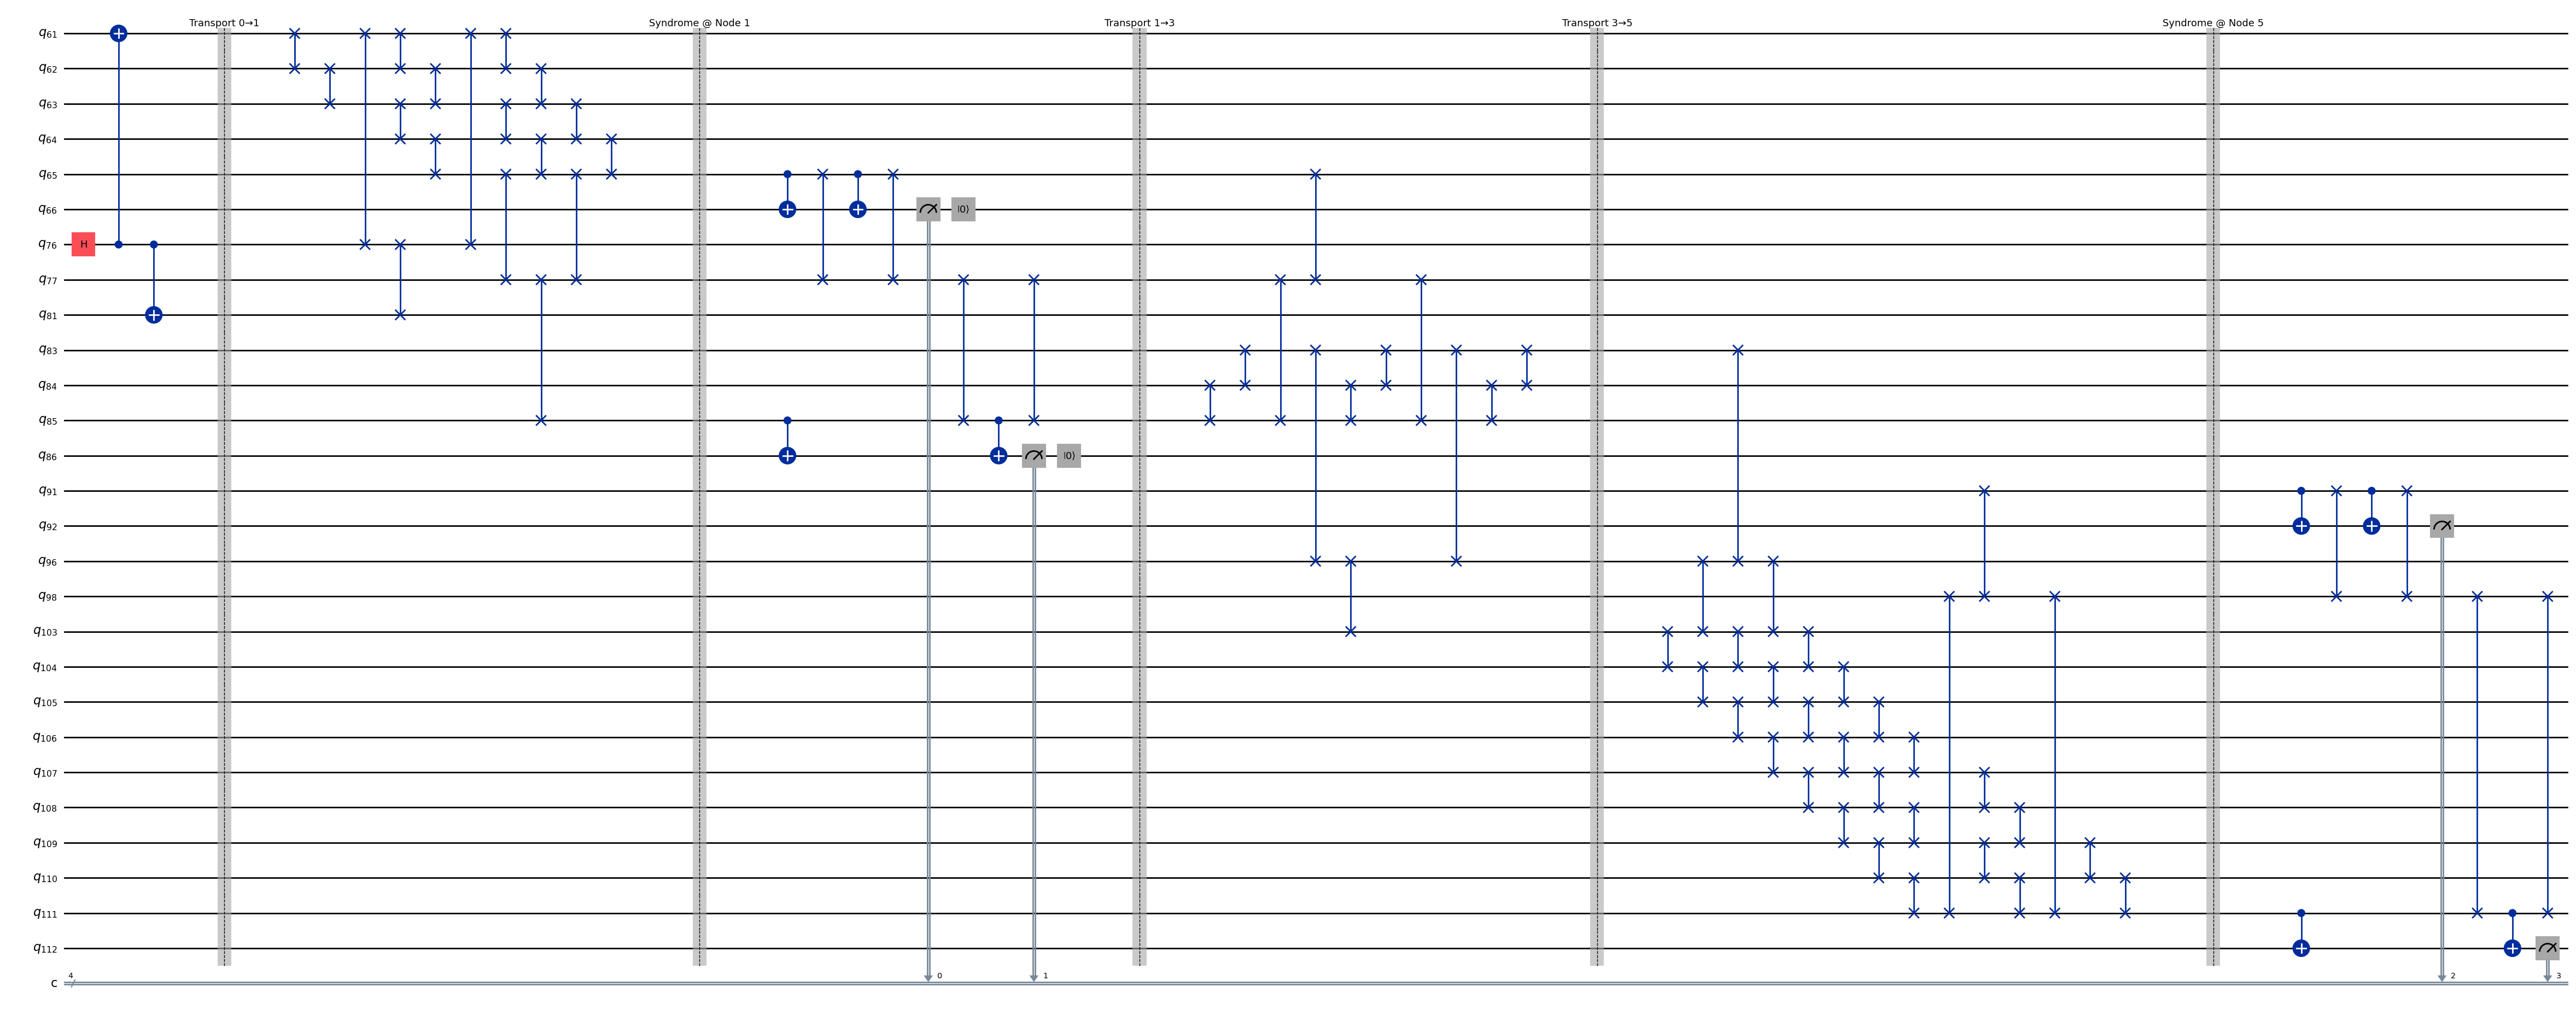

In [13]:
multihop_circuit_1.draw('mpl', fold=-1, idle_wires=False)

In [14]:
from qiskit import transpile

transpiled_multihop = transpile(
    multihop_circuit_1,
    backend,
    initial_layout=list(range(backend.num_qubits)),
    optimization_level=0
)



In [15]:
transpiled_multihop.draw('mpl', fold=-1, idle_wires=False)